# Two Gaussian example with a linear invertible function - $x = az + b$ #

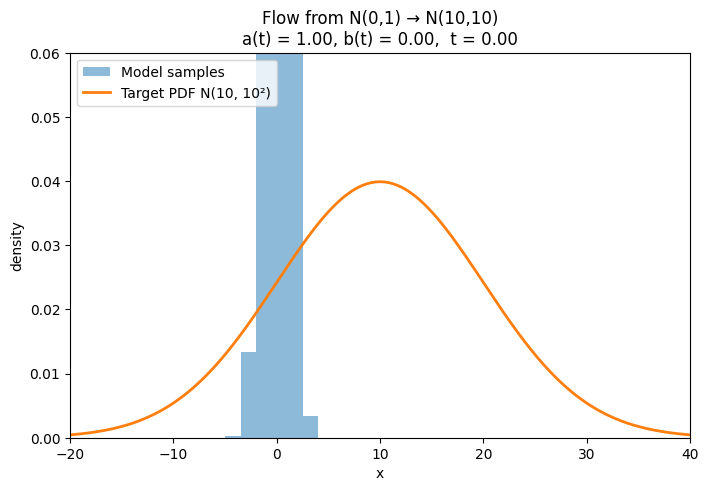

In [2]:
import numpy as np
import scipy as sc
import scipy.integrate as integ
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation



# Target distibrution data points:
x = np.random.normal(10, 10, 1000)


# Target analytic PDF for plotting
def target_pdf(x, mean=10.0, std=10.0):
    return (1.0 / (std * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)


# Invertible Function Definition
def linear_inv_func(x,a,b):
    return (x - b) / a

def p_0_gaus(x):
    return 1 / (np.sqrt(2 * np.pi)) * np.exp(-0.5 * (x ** 2))

# BUild the objective function
def objective_gaus(params, x):
    a, b = params
    p_0 = p_0_gaus(linear_inv_func(x, a, b))
    det = 1 / np.abs(a)
    p_t = p_0 * det
    eps = 1e-12
    return -np.sum(np.log(p_t + eps))
    # return p_t
# initial values
initial_params = np.array([1.0, 0.0])  # start from N(0,1)
a0, b0 = initial_params
# minimize
res = minimize(objective_gaus, initial_params, method='nelder-mead', args=(x, ))
res = minimize(
    objective_gaus,
    initial_params,
    args=(x,),
    method="Nelder-Mead"
)
a_hat, b_hat = res.x
def update(frame_idx):
    ax.clear()

    # interpolation factor t from 0 to 1
    t = frame_idx / (n_frames - 1)

    # interpolate parameters from (a0,b0) -> (a_hat,b_hat)
    a_t = (1 - t) * a0 + t * a_hat
    b_t = (1 - t) * b0 + t * b_hat

    # transform z-samples with current parameters
    x_model = a_t * z_samples + b_t

    # plot histogram of model samples
    ax.hist(
        x_model,
        bins=40,
        range=(x_min, x_max),
        density=True,
        alpha=0.5,
        label="Model samples"
    )

    # plot the true target PDF
    ax.plot(x_grid, true_pdf_vals, lw=2, label="Target PDF N(10, 10²)")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 0.06)
    ax.set_xlabel("x")
    ax.set_ylabel("density")
    ax.set_title(
        f"Flow from N(0,1) → N(10,10)\n"
        f"a(t) = {a_t:.2f}, b(t) = {b_t:.2f},  t = {t:.2f}"
    )
    ax.legend(loc="upper left")

    # Return artists if you ever want blitting=True
    return []

rng = np.random.default_rng(0)  # reproducible

z_samples = rng.normal(loc=0.0, scale=1.0, size=5000)

# ---------------------------------------------------------------------
# 7. Set up the animation
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# x-range for plotting true target PDF
x_min, x_max = -20, 40
x_grid = np.linspace(x_min, x_max, 500)
true_pdf_vals = target_pdf(x_grid, mean=10.0, std=10.0)


n_frames = 60



anim = FuncAnimation(fig, update, frames=n_frames, interval=100, blit=False)

# ---------------------------------------------------------------------
# 8A. If you're running in a JUPYTER NOTEBOOK:
# ---------------------------------------------------------------------
from IPython.display import HTML
HTML(anim.to_jshtml())




# Two Gaussians Example with invertible function : $x = az^3 + b$ #

Optimization result: 0 Optimization terminated successfully.
Estimated parameters: a = 10.452597, b = 0.008869
Sample mean of data: 9.7197
Sample std of data:  10.0020


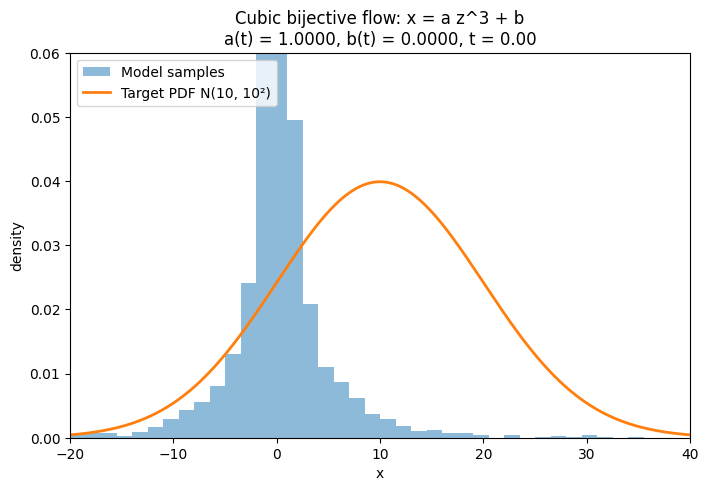

In [3]:

import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ---------------------------------------------------------------------
# 1. Generate target data: N(mean=10, std=10)
# ---------------------------------------------------------------------
rng = np.random.default_rng(0)  # reproducible
x_data = rng.normal(loc=10.0, scale=10.0, size=2000)

# ---------------------------------------------------------------------
# 2. Base distribution p0(z) = N(0,1)
# ---------------------------------------------------------------------
def p0_gaussian(z):
    """Standard normal PDF."""
    return (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * z**2)

def target_pdf(x, mean=10.0, std=10.0):
    """Target analytic PDF for plotting (Gaussian)."""
    return (1.0 / (std * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)

# ---------------------------------------------------------------------
# 3. Bijective cubic flow
#    Forward:  x = f(z) = a * z^3 + b
#    Inverse:  z = f^{-1}(x) = ((x - b)/a)^(1/3)   (real cube root)
#    Jacobian: dx/dz = 3 a z^2  => |dz/dx| = 1/|3 a z^2|
# ---------------------------------------------------------------------
def cbrt_real(y):
    """Real cube root that works for negative inputs."""
    y = np.asarray(y, dtype=float)
    return np.sign(y) * np.abs(y) ** (1.0 / 3.0)

def forward_flow(z, a, b):
    return a * z**3 + b

def inverse_flow(x, a, b):
    # z = cbrt((x-b)/a)
    return cbrt_real((x - b) / a)

def log_abs_det_jacobian(x, a, b):
    """
    log |dz/dx| evaluated via z(x):
      dz/dx = 1/(dx/dz) = 1/(3 a z^2)
    """
    z = inverse_flow(x, a, b)
    # avoid log(0) at z=0
    return -np.log(np.abs(3.0 * a * z**2) + 1e-12)

# ---------------------------------------------------------------------
# 4. Negative log-likelihood objective for (a, b)
# ---------------------------------------------------------------------
def objective(params, x):
    a, b = params

    # a must be nonzero for bijection
    if np.abs(a) < 1e-8:
        return 1e12

    z = inverse_flow(x, a, b)
    log_p0 = -0.5 * z**2 - 0.5 * np.log(2.0 * np.pi)
    log_jac = log_abs_det_jacobian(x, a, b)  # log|dz/dx|
    eps = 1e-12
    log_px = log_p0 + log_jac + eps

    nll = -np.sum(log_px)

    # mild regularization helps keep optimizer sane
    nll += 1e-4 * (a**2 + b**2)
    return nll

# ---------------------------------------------------------------------
# 5. Optimize (a, b) by maximum likelihood
# ---------------------------------------------------------------------
initial_params = np.array([1.0, 0.0])  # start with x = z^3
res = minimize(
    objective,
    initial_params,
    args=(x_data,),
    method="Nelder-Mead",
    options={"maxiter": 50_000, "xatol": 1e-10, "fatol": 1e-10}
)

a_hat, b_hat = res.x
print("Optimization result:", res.status, res.message)
print(f"Estimated parameters: a = {a_hat:.6f}, b = {b_hat:.6f}")
print(f"Sample mean of data: {np.mean(x_data):.4f}")
print(f"Sample std of data:  {np.std(x_data):.4f}")

# ---------------------------------------------------------------------
# 6. Prepare base samples for the animation
# ---------------------------------------------------------------------
z_samples = rng.normal(loc=0.0, scale=1.0, size=5000)

# ---------------------------------------------------------------------
# 7. Set up the animation
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

x_min, x_max = -20, 40
x_grid = np.linspace(x_min, x_max, 500)
true_pdf_vals = target_pdf(x_grid, mean=10.0, std=10.0)

n_frames = 60
a0, b0 = initial_params

def update(frame_idx):
    ax.clear()

    t = frame_idx / (n_frames - 1)

    # interpolate parameters from (a0,b0) -> (a_hat,b_hat)
    a_t = (1 - t) * a0 + t * a_hat
    b_t = (1 - t) * b0 + t * b_hat

    # ensure we never hit exactly a=0 during interpolation
    if np.abs(a_t) < 1e-8:
        a_t = np.sign(a_t) * 1e-8 if a_t != 0 else 1e-8

    # transform z-samples with current parameters
    x_model = forward_flow(z_samples, a_t, b_t)

    ax.hist(
        x_model,
        bins=40,
        range=(x_min, x_max),
        density=True,
        alpha=0.5,
        label="Model samples"
    )

    ax.plot(x_grid, true_pdf_vals, lw=2, label="Target PDF N(10, 10²)")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 0.06)
    ax.set_xlabel("x")
    ax.set_ylabel("density")
    ax.set_title(
        f"Cubic bijective flow: x = a z^3 + b\n"
        f"a(t) = {a_t:.4f}, b(t) = {b_t:.4f}, t = {t:.2f}"
    )
    ax.legend(loc="upper left")
    return []

anim = FuncAnimation(fig, update, frames=n_frames, interval=100, blit=False)

# ---------------------------------------------------------------------
# 8A. If you're running in a JUPYTER NOTEBOOK:
# ---------------------------------------------------------------------
from IPython.display import HTML
HTML(anim.to_jshtml())

# ---------------------------------------------------------------------
# 8B. If you're running as a plain .py script:
# ---------------------------------------------------------------------
# plt.show()
# anim.save("flow_cubic.gif", writer="pillow", fps=10)
# anim.save("flow_cubic.mp4", writer="ffmpeg", fps=10)


# Same Procedure but with an invertible function of - $x = b+az+clog(1+ez)$ #

Optimization result: 0 Optimization terminated successfully.
Estimated parameters: a = 10.001970, b = 9.719734, c = 0.000000
Sample mean of data: 9.7197
Sample std  of data: 10.0020


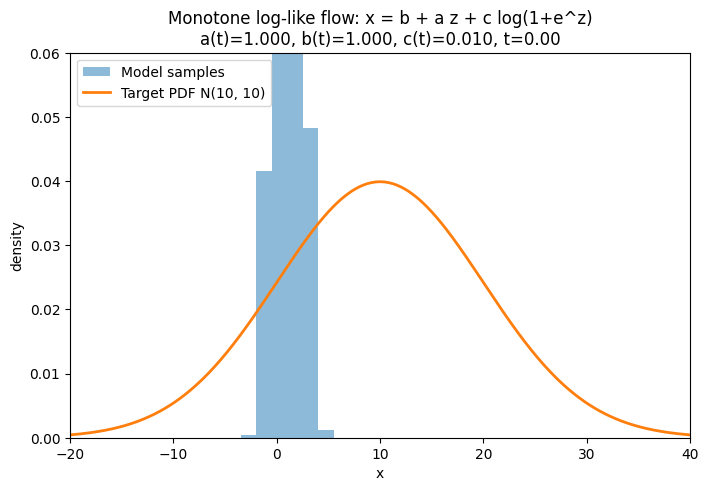

In [2]:

import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ---------------------------------------------------------------------
# 1. Generate target data: N(mean=10, std=10)
# ---------------------------------------------------------------------
rng = np.random.default_rng(0)
x_data = rng.normal(loc=10.0, scale=10.0, size=2000)

# ---------------------------------------------------------------------
# 2. Base distribution p0(z) = N(0,1)
# ---------------------------------------------------------------------
def p0_logpdf(z):
    return -0.5 * z**2 - 0.5 * np.log(2.0 * np.pi)

def target_pdf(x, mean=10.0, std=10.0):
    return (1.0 / (std * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)

# ---------------------------------------------------------------------
# 3. "Log-like" bijective flow: x = b + a z + c softplus(z)
#    softplus(z) = log(1 + exp(z))  (stable implementation below)
#    f'(z) = a + c * sigmoid(z)  >= a  (if a>0, c>=0) => strictly monotone => bijection
# ---------------------------------------------------------------------
def softplus(z):
    # Stable softplus: log(1+exp(z))
    z = np.asarray(z, dtype=float)
    return np.log1p(np.exp(-np.abs(z))) + np.maximum(z, 0.0)

def sigmoid(z):
    z = np.asarray(z, dtype=float)
    # Stable sigmoid
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

def forward_flow(z, a, b, c):
    return b + a * z + c * softplus(z)

def dfdz(z, a, c):
    return a + c * sigmoid(z)

def inverse_flow_newton(x, a, b, c, *, max_iter=60, tol=1e-10):
    """
    Solve f(z)=x for z with Newton iterations (vectorized).
    Good initial guess: (x-b)/a.
    """
    x = np.asarray(x, dtype=float)
    z = (x - b) / a  # initial guess

    for _ in range(max_iter):
        f = forward_flow(z, a, b, c) - x
        fp = dfdz(z, a, c)

        step = f / fp
        z_new = z - step

        if np.max(np.abs(step)) < tol:
            z = z_new
            break

        z = z_new

    return z

# ---------------------------------------------------------------------
# 4. Negative log-likelihood objective
#    We optimize unconstrained params (alpha, b, gamma) with:
#      a = exp(alpha) + a_min  (forces a>0)
#      c = exp(gamma)          (forces c>=0)
# ---------------------------------------------------------------------
A_MIN = 1e-3

def unpack(params):
    alpha, b, gamma = params
    a = np.exp(alpha) + A_MIN
    c = np.exp(gamma)
    return a, b, c

def objective(params, x):
    a, b, c = unpack(params)

    # Invert x -> z
    z = inverse_flow_newton(x, a, b, c)

    # log p(x) = log p0(z) + log|dz/dx| = log p0(z) - log f'(z)
    log_px = p0_logpdf(z) - np.log(np.abs(dfdz(z, a, c)) + 1e-12)
    nll = -np.sum(log_px)

    # mild regularization
    nll += 1e-5 * (a**2 + b**2 + c**2)
    return nll

# ---------------------------------------------------------------------
# 5. Optimize parameters
# ---------------------------------------------------------------------
# Start near the linear map: x ~ b + a z
# data mean~10 => b~10; data std~10 => a~10; start c small
init_alpha = np.log(1 - A_MIN)
init_b = 1
init_gamma = np.log(1e-2)  # c ~ 0.01
initial_params = np.array([init_alpha, init_b, init_gamma], dtype=float)

res = minimize(
    objective,
    initial_params,
    args=(x_data,),
    method="Nelder-Mead",
    options={"maxiter": 50_000, "xatol": 1e-9, "fatol": 1e-9}
)

a_hat, b_hat, c_hat = unpack(res.x)
print("Optimization result:", res.status, res.message)
print(f"Estimated parameters: a = {a_hat:.6f}, b = {b_hat:.6f}, c = {c_hat:.6f}")
print(f"Sample mean of data: {np.mean(x_data):.4f}")
print(f"Sample std  of data: {np.std(x_data):.4f}")

# ---------------------------------------------------------------------
# 6. Base samples for animation
# ---------------------------------------------------------------------
z_samples = rng.normal(loc=0.0, scale=1.0, size=5000)

# ---------------------------------------------------------------------
# 7. Animation setup
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

x_min, x_max = -20, 40
x_grid = np.linspace(x_min, x_max, 500)
true_pdf_vals = target_pdf(x_grid, mean=10.0, std=10.0)

n_frames = 60
a0, b0, c0 = unpack(initial_params)

def update(frame_idx):
    ax.clear()
    t = frame_idx / (n_frames - 1)

    # interpolate in the actual (a,b,c) space
    a_t = (1 - t) * a0 + t * a_hat
    b_t = (1 - t) * b0 + t * b_hat
    c_t = (1 - t) * c0 + t * c_hat

    x_model = forward_flow(z_samples, a_t, b_t, c_t)

    ax.hist(
        x_model,
        bins=40,
        range=(x_min, x_max),
        density=True,
        alpha=0.5,
        label="Model samples"
    )
    ax.plot(x_grid, true_pdf_vals, lw=2, label="Target PDF N(10, 10)")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 0.06)
    ax.set_xlabel("x")
    ax.set_ylabel("density")
    ax.set_title(
        "Monotone log-like flow: x = b + a z + c log(1+e^z)\n"
        f"a(t)={a_t:.3f}, b(t)={b_t:.3f}, c(t)={c_t:.3f}, t={t:.2f}"
    )
    ax.legend(loc="upper left")
    return []

anim = FuncAnimation(fig, update, frames=n_frames, interval=100, blit=False)

# ---------------------------------------------------------------------
# 8A. Jupyter
# ---------------------------------------------------------------------
from IPython.display import HTML
HTML(anim.to_jshtml())

# ---------------------------------------------------------------------
# 8B. Script mode
# ---------------------------------------------------------------------
# plt.show()
# anim.save("flow_softplus.gif", writer="pillow", fps=10)
# anim.save("flow_softplus.mp4", writer="ffmpeg", fps=10)


# Normalizing Flow of a particle in a box #

(array([0.01 , 0.025, 0.06 , 0.12 , 0.16 , 0.27 , 0.315, 0.465, 0.455,
        0.6  , 0.505, 0.58 , 0.705, 0.71 , 0.6  , 0.625, 0.575, 0.535,
        0.64 , 0.555, 0.61 , 0.63 , 0.645, 0.875, 0.92 , 1.105, 1.265,
        1.255, 1.6  , 1.925, 2.19 , 2.155, 2.455, 2.34 , 2.525, 2.655,
        2.355, 2.29 , 2.05 , 2.1  , 1.76 , 1.62 , 1.315, 1.02 , 0.735,
        0.57 , 0.275, 0.175, 0.055, 0.02 ]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]),
 <BarContainer object of 50 artists>)

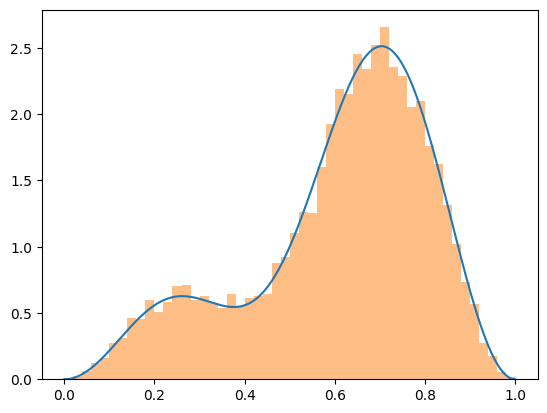

In [5]:
from scipy.interpolate import PchipInterpolator  # monotone
from scipy.integrate import cumulative_trapezoid


L = 1
h_bar = 1
m = 1
E_1 = h_bar**2 * np.pi**2 / (2 * m * L**2)
E_2 = 4 * h_bar**2 * np.pi**2 / (2 * m * L**2)
t_end = 1
t_grid = np.linspace(0, t_end, 1000)
N = 10000
x = np.linspace(0,L,N)
dx = x[1] - x[0]

def rho_target(x, t=t_end, L=L, E_1=E_1, E_2=E_2, h_bar=h_bar, norm=True):
    term_1 = np.square(np.sin(np.pi * x / L))
    term_2 = np.square(np.sin(2 * np.pi * x / L))
    term_3 = 2 * np.sin(np.pi * x / L) * np.sin(2 * np.pi * x / L) * np.cos((E_2 - E_1) * t / h_bar)
    rho = 1 / L * (term_1 + term_2 + term_3)
    dx = x[1] - x[0]
    rho = np.clip(rho, 0.0, None)

    if norm:
        pdf = rho / (np.sum(rho) * dx)
    return pdf

def inverse_cdf_porpogator(rho_func, L=L, t=t_end, n_grid=20_000, eps=1e-10):
    x = np.linspace(0, L, n_grid)
    rho = rho_func(x, t=t, L=L, eps=eps)





# sampling the
rng = np.random.default_rng()
plt.plot(x, rho_target(x), label="Target density")
p = rho_target(x) * dx
p = p / p.sum()

x_data = rng.choice(x, size=N, p=p)
plt.hist(x_data, density=True, range=(0.0, 1.0), alpha=0.5, label="Target density",bins=50)



In [4]:
import torch
import torch.nn as nn
import numpy as np
import math
import matplotlib.pyplot as plt


# Contants
L = 1
h_bar = 1
m = 1
E_1 = h_bar**2 * math.pi**2 / (2 * m * L**2)
E_2 = 4 * h_bar**2 * math.pi**2 / (2 * m * L**2)
t_end = 1
t_grid = torch.linspace(0, t_end, 1000)


class PotentialNN(nn.Module):
    """
    Real-valued potential V_theta(x) on x in [0, L].
    - Normalizes input to [-1, 1]
    - Uses an MLP
    - Optionally bounds output with tanh for stability
    """
    def __init__(self, L: float, hidden=(64, 64), Vmax=10.0, bounded=True, trace=False):
        super().__init__()
        self.L = float(L)
        self.Vmax = float(Vmax)
        self.bounded = bounded

        layers = []
        in_dim = 1
        for h in hidden:
            if trace:
                print(h)
            layers += [nn.Linear(in_dim, h), nn.Tanh()]
            in_dim = h
        layers += [nn.Linear(in_dim, 1)]
        if trace:
            print(layers)
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: shape (N,) or (N,1), in [0, L]
        returns: V(x), shape (N,)
        """
        if x.ndim == 1:
            x = x[:, None]  # (N,1)

        # normalize x in [0,L] -> xhat in [-1,1]
        xhat = 2.0 * (x / self.L) - 1.0

        y = self.net(xhat)  # (N,1)
        if self.bounded:
            y = self.Vmax * torch.tanh(y)  # keep V in [-Vmax, Vmax]
        return y[:, 0]  # (N,)


def kineteic_energy_operator(x):
    dx = x[1] - x[0]
    n = x.numel()
    # device, dtype = x.device, x.dtype

    main = -2.0 * torch.ones(n)#, device=device, dtype=dtype)
    off  =  1.0 * torch.ones(n - 1)#, device=device, dtype=dtype)

    D2 = torch.diag(main) + torch.diag(off, diagonal=1) + torch.diag(off, diagonal=-1)
    D2 = D2 / (dx * dx)
    return D2

def p_0_gaus(x, mean=0, std=1):
    return 1 / (np.sqrt(2 * math.pi)) * torch.exp(-0.5 * ((x-mean) ** 2)/ std ** 2)


import torch

def rho_target(x, t=t_end, L=L, E_1=E_1, E_2=E_2, h_bar=h_bar, norm=True, eps=0.0):
    # ensure scalar params are tensors compatible with x
    dtype, device = x.dtype, x.device
    t     = torch.as_tensor(t,     dtype=dtype, device=device)
    L     = torch.as_tensor(L,     dtype=dtype, device=device)
    E_1   = torch.as_tensor(E_1,   dtype=dtype, device=device)
    E_2   = torch.as_tensor(E_2,   dtype=dtype, device=device)
    h_bar = torch.as_tensor(h_bar, dtype=dtype, device=device)

    term_1 = torch.sin(torch.pi * x / L) ** 2
    term_2 = torch.sin(2.0 * torch.pi * x / L) ** 2

    phase  = (E_2 - E_1) * t / h_bar
    term_3 = 2.0 * torch.sin(torch.pi * x / L) * torch.sin(2.0 * torch.pi * x / L) * torch.cos(phase)

    rho = (1.0 / L) * (term_1 + term_2 + term_3)

    dx = x[1] - x[0]
    rho = torch.clamp(rho, min=0.0)

    if norm:
        pdf = rho / (torch.sum(rho) * dx + eps)
        return pdf
    return rho


from scipy.interpolate import PchipInterpolator  # monotone
from scipy.integrate import cumulative_trapezoid


N = 10000
dx = L / (N + 1)
x_grid = torch.linspace(dx, L - dx, N)  # interior points only

# initial State Definition
psi0 = p_0_gaus(x_grid, mean=.5, std=.1)
E_k = kineteic_energy_operator(x_grid)
V_model = PotentialNN(L=L, hidden=(64, 64), Vmax=20.0, bounded=True, trace=False)
V = V_model(x_grid)  # shape (N,), real
H = V + E_k


# gather data from known distribution
p = rho_target(x_grid) * dx
p = p / p.sum()

M = 216
idx_data = torch.multinomial(p, num_samples=M, replacement=True)
x_data = x_grid[idx_data]

eps = 1e-12
optimizer = torch.optim.Adam(V_model.parameters(), lr=1e-3)

rho_tgt = rho_target(x_grid, t=t_end, L=L, E_1=E_1, E_2=E_2, h_bar=h_bar, norm=True).detach()
num_steps = 100
for step in range(num_steps):
    optimizer.zero_grad()

    # 1) Build H_theta
    V_vec = V_model(x_grid)                 # (N,) depends on NN params theta
    H = E_k + torch.diag(V_vec)               # (N,N)

    # 2) Propagate psi with U_theta(t) using eigh
    evals, Q = torch.linalg.eigh(H)         # differentiable
    phase = torch.exp(-1j * evals * (t_end / h_bar))
    psi_t = Q @ (phase * (Q.T @ psi0))      # apply U without forming diag

    # 3) Density
    rho = (psi_t.conj() * psi_t).real
    rho = rho / (rho.sum() * dx + eps)

    # 4) Loss (cross-entropy / KL direction)
    loss = torch.sum(rho_tgt * (-torch.log(rho + eps))) * dx

    # (optional) regularize V for smoothness
    dV = (V_vec[1:] - V_vec[:-1]) / dx
    loss = loss + 1e-3 * torch.sum(dV**2) * dx

    # 5) Backprop + update theta
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(step, float(loss))


plt.title('Target Distribution & Sampled Data')
plt.hist(x_data, density=True, bins=100, alpha=0.5, label='data')
plt.plot(x_grid, rho_target(x_grid, t=t_end))
plt.show()


RuntimeError: expected scalar type Float but found ComplexFloat

step    0 | loss=0.025342 | data=0.023302
step   50 | loss=-0.091820 | data=-0.127701
step  100 | loss=-0.096800 | data=-0.133935
step  150 | loss=-0.097091 | data=-0.133820
step  200 | loss=-0.097459 | data=-0.134208
step  250 | loss=-0.097718 | data=-0.134404
step  300 | loss=-0.097797 | data=-0.134441
step  350 | loss=-0.097830 | data=-0.134472
step  400 | loss=-0.097858 | data=-0.134512
step  450 | loss=-0.097886 | data=-0.134554
step  500 | loss=-0.097914 | data=-0.134598
step  550 | loss=-0.097943 | data=-0.134645
step  600 | loss=-0.097974 | data=-0.134696
step  650 | loss=-0.098009 | data=-0.134755
step  700 | loss=-0.098052 | data=-0.134830
step  750 | loss=-0.097954 | data=-0.136814
step  800 | loss=-0.098145 | data=-0.134757
step  850 | loss=-0.098232 | data=-0.135168
step  900 | loss=-0.098371 | data=-0.135443
step  950 | loss=-0.098519 | data=-0.135507
step 1000 | loss=-0.098632 | data=-0.135966
step 1050 | loss=-0.098718 | data=-0.136269
step 1100 | loss=-0.098783 | data=

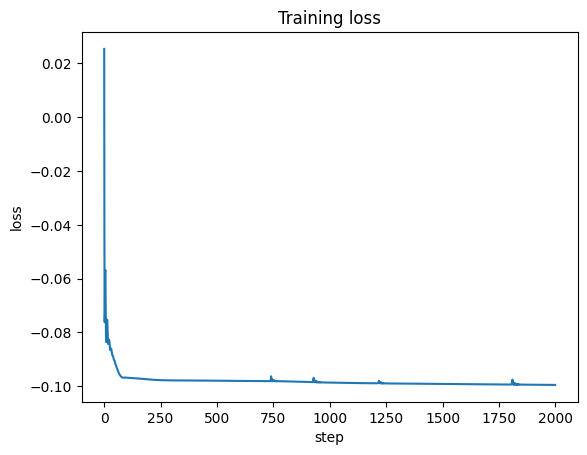

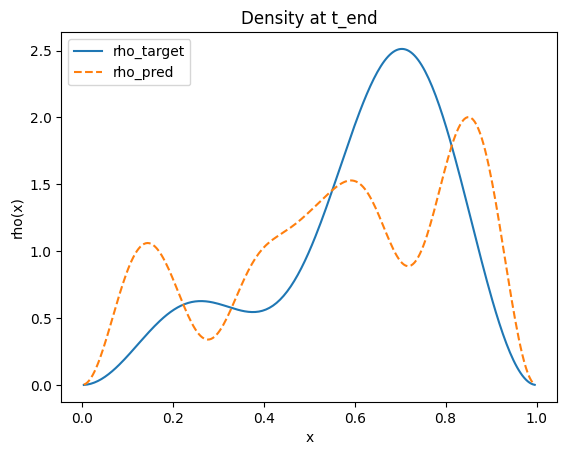

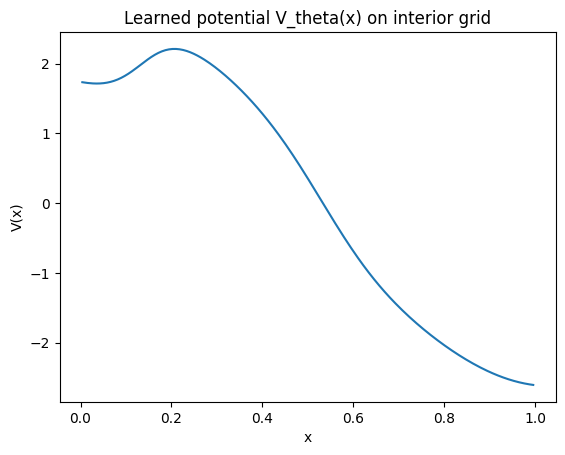

In [5]:
# --- Full working example: learn V_theta(x) so that evolution under H = T + V
# --- maps an initial (Gaussian) wavefunction to a target particle-in-a-box density.

import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -----------------------------
# 0) Device / dtype
# -----------------------------
device = torch.device("cpu")  # change to "cuda" if you want and have it
real_dtype = torch.float64
cplx_dtype = torch.complex128

torch.manual_seed(0)

# -----------------------------
# 1) Physics / problem settings
# -----------------------------
L = 1.0
h_bar = 1.0
m = 1.0
t_end = 1.0

def E_n(n, L=L, h_bar=h_bar, m=m):
    return (n**2) * (h_bar**2) * (math.pi**2) / (2.0 * m * (L**2))

E_1 = E_n(1)
E_2 = E_n(2)

# -----------------------------
# 2) Target density (your function in torch)
# -----------------------------
import torch

def rho_target_torch(x, t, L, E_1, E_2, h_bar, norm=True, eps=1e-15):
    """
    x: torch.Tensor (N,)
    t, L, E_1, E_2, h_bar can be floats or tensors.
    Returns pdf on the same device/dtype as x.
    """
    # Make the phase a tensor (so torch.cos works)
    phase = (E_2 - E_1) * t / h_bar
    phase = torch.as_tensor(phase, device=x.device, dtype=x.dtype)

    term_1 = torch.sin(torch.pi * x / L) ** 2
    term_2 = torch.sin(2.0 * torch.pi * x / L) ** 2
    term_3 = 2.0 * torch.sin(torch.pi * x / L) * torch.sin(2.0 * torch.pi * x / L) * torch.cos(phase)

    rho = (1.0 / L) * (term_1 + term_2 + term_3)
    rho = torch.clamp(rho, min=0.0)

    if norm:
        dx = x[1] - x[0]
        rho = rho / (torch.sum(rho) * dx + eps)

    return rho

# -----------------------------
# 3) Initial state (Gaussian wavefunction)
# -----------------------------
def psi0_gaussian(x, mean=0.5, std=0.1):
    # real wavefunction ~ Gaussian; we'll normalize it in L2 later
    return torch.exp(-0.5 * ((x - mean) / std) ** 2)

# -----------------------------
# 4) Kinetic energy operator matrix (finite difference)
# -----------------------------
def kinetic_energy_matrix(N, dx, h_bar=1.0, m=1.0, device=device, dtype=real_dtype):
    main = (-2.0) * torch.ones(N, device=device, dtype=dtype)
    off  = (1.0)  * torch.ones(N - 1, device=device, dtype=dtype)

    D2 = torch.diag(main) + torch.diag(off, diagonal=1) + torch.diag(off, diagonal=-1)
    D2 = D2 / (dx * dx)

    T = -(h_bar**2) / (2.0 * m) * D2
    return T  # (N,N), real symmetric

# -----------------------------
# 5) Potential NN V_theta(x)
# -----------------------------
class PotentialNN(nn.Module):
    def __init__(self, L: float, hidden=(64, 64), Vmax=20.0, bounded=True):
        super().__init__()
        self.L = float(L)
        self.Vmax = float(Vmax)
        self.bounded = bounded

        layers = []
        in_dim = 1
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.Tanh()]
            in_dim = h
        layers += [nn.Linear(in_dim, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (N,) or (N,1), values in [0,L]
        if x.ndim == 1:
            x = x[:, None]  # (N,1)

        # normalize to [-1,1]
        xhat = 2.0 * (x / self.L) - 1.0

        y = self.net(xhat)  # (N,1)
        if self.bounded:
            y = self.Vmax * torch.tanh(y)
        return y[:, 0]  # (N,)

# -----------------------------
# 6) Propagate: psi(t) = exp(-i H t / ħ) psi0 using eigen-decomposition
# -----------------------------
def propagate_with_eigh(H_real, psi0_cplx, t, h_bar=1.0):
    """
    H_real: (N,N) real symmetric tensor (float64 recommended)
    psi0_cplx: (N,) complex tensor
    returns psi_t: (N,) complex tensor
    """
    evals, Q = torch.linalg.eigh(H_real)  # evals float, Q float
    phase = torch.exp((-1j) * evals * (t / h_bar))  # complex

    Qc = Q.to(psi0_cplx.dtype)  # cast eigenvectors to complex
    psi_t = Qc @ (phase * (Qc.T @ psi0_cplx))
    return psi_t

# -----------------------------
# 7) Main: build grid, model, and train
# -----------------------------
# IMPORTANT: start small; dense eigendecomposition is O(N^3).
N = 256  # try 128/256 first; 512 is already heavy
dx = L / (N + 1)
x_grid = torch.linspace(dx, L - dx, N, device=device, dtype=real_dtype)

# Build fixed kinetic matrix
T = kinetic_energy_matrix(N, dx, h_bar=h_bar, m=m, device=device, dtype=real_dtype)

# Initial wavefunction (complex)
psi0 = psi0_gaussian(x_grid, mean=0.5, std=0.1).to(cplx_dtype)
# Normalize wavefunction: ∫|psi|^2 dx = 1
psi0 = psi0 / torch.sqrt(torch.sum((psi0.conj() * psi0).real) * dx)

# Target density on grid (detach: not a function of NN params)
rho_tgt = rho_target_torch(x_grid, t=t_end, L=L, E_1=E_1, E_2=E_2, h_bar=h_bar, norm=True).detach()

# Model + optimizer
V_model = PotentialNN(L=L, hidden=(64, 64, 64), Vmax=20.0, bounded=True).to(device=device, dtype=real_dtype)
optimizer = torch.optim.Adam(V_model.parameters(), lr=1e-3)

# Training hyperparameters
num_steps = 2000
eps = 1e-12
lam_smooth = 1e-3
lam_mag = 1e-5

loss_history = []

for step in range(num_steps):
    optimizer.zero_grad()

    # Potential (vector) and Hamiltonian (matrix)
    V_vec = V_model(x_grid)                  # (N,) float64; depends on NN params
    H = T + torch.diag(V_vec)                # (N,N) float64

    # Propagate under H
    psi_t = propagate_with_eigh(H, psi0, t=t_end, h_bar=h_bar)

    # Predicted density
    rho = (psi_t.conj() * psi_t).real
    rho = rho / (torch.sum(rho) * dx + eps)  # normalize to pdf

    # Loss: cross-entropy vs target (equiv to KL up to a constant)
    loss_data = torch.sum(rho_tgt * (-torch.log(rho + eps))) * dx

    # Regularization: smoothness + magnitude (helps identifiability / stability)
    dV = (V_vec[1:] - V_vec[:-1]) / dx
    loss_smooth = torch.sum(dV**2) * dx
    loss_mag = torch.sum(V_vec**2) * dx

    loss = loss_data + lam_smooth * loss_smooth + lam_mag * loss_mag
    loss.backward()
    optimizer.step()

    loss_history.append(float(loss))

    if step % 50 == 0:
        print(f"step {step:4d} | loss={loss.item():.6f} | data={loss_data.item():.6f}")

# -----------------------------
# 8) Plot results
# -----------------------------
with torch.no_grad():
    V_learned = V_model(x_grid).cpu()
    H = (T + torch.diag(V_model(x_grid))).detach()
    psi_t = propagate_with_eigh(H, psi0, t=t_end, h_bar=h_bar)
    rho_pred = ((psi_t.conj() * psi_t).real)
    rho_pred = rho_pred / (rho_pred.sum() * dx + eps)
    rho_pred = rho_pred.cpu()
    rho_tgt_cpu = rho_tgt.cpu()
    x_cpu = x_grid.cpu()

plt.figure()
plt.plot(loss_history)
plt.title("Training loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

plt.figure()
plt.plot(x_cpu, rho_tgt_cpu, label="rho_target")
plt.plot(x_cpu, rho_pred, "--", label="rho_pred")
plt.title("Density at t_end")
plt.xlabel("x")
plt.ylabel("rho(x)")
plt.legend()
plt.show()

plt.figure()
plt.plot(x_cpu, V_learned)
plt.title("Learned potential V_theta(x) on interior grid")
plt.xlabel("x")
plt.ylabel("V(x)")
plt.show()


step    0 | loss=1.0117 | nll=1.0086 | phys=33288724.7630 | lam_phys=0.000 | Vsm=1.5501
step  200 | loss=-5.1953 | nll=-5.1953 | phys=191909.3063 | lam_phys=0.000 | Vsm=0.0013
step  400 | loss=-5.5350 | nll=-5.5350 | phys=281645.0995 | lam_phys=0.000 | Vsm=0.0006
step  600 | loss=88.2018 | nll=-3.7755 | phys=133.0163 | lam_phys=0.667 | Vsm=1649.9118
step  800 | loss=1681.9166 | nll=-4.2742 | phys=1263.3878 | lam_phys=1.333 | Vsm=836.8827
step 1000 | loss=1930.3376 | nll=-2.7781 | phys=966.5579 | lam_phys=2.000 | Vsm=0.0001
step 1200 | loss=97.9404 | nll=-1.4754 | phys=49.7079 | lam_phys=2.000 | Vsm=0.0001
step 1400 | loss=17.0797 | nll=-1.0753 | phys=9.0775 | lam_phys=2.000 | Vsm=0.0001


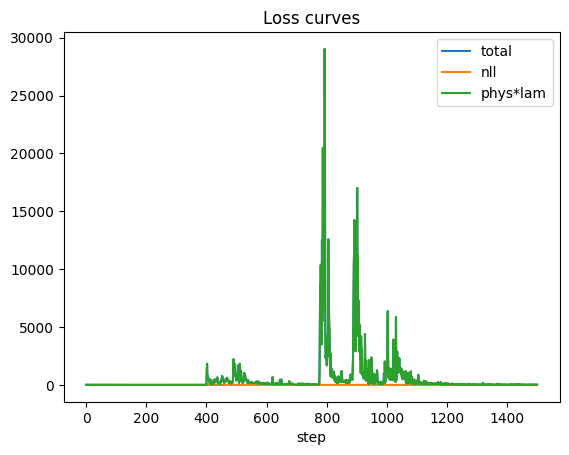

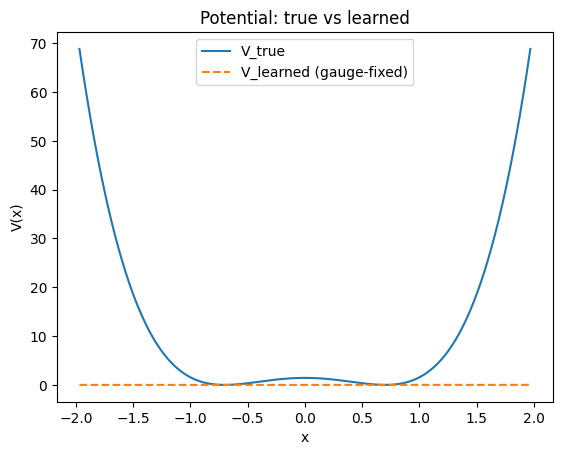

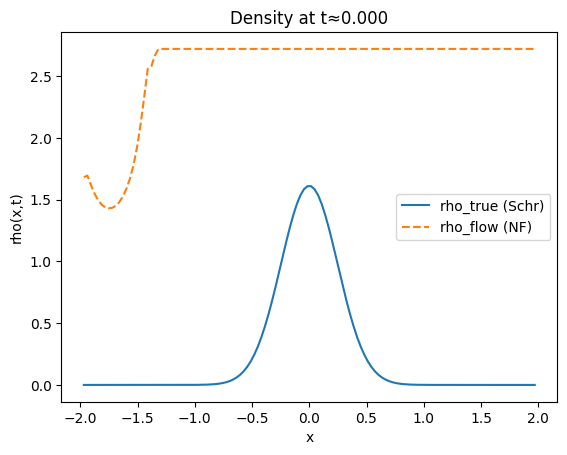

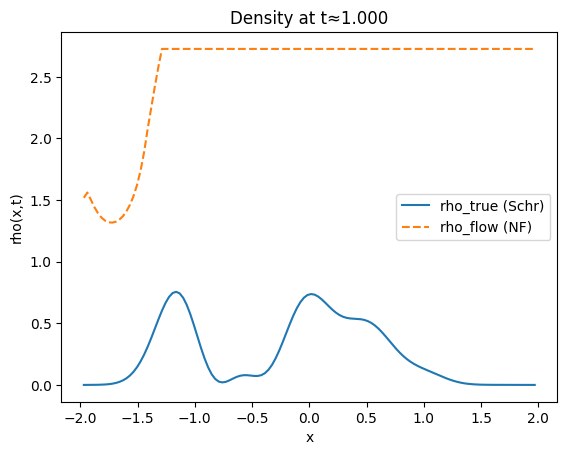

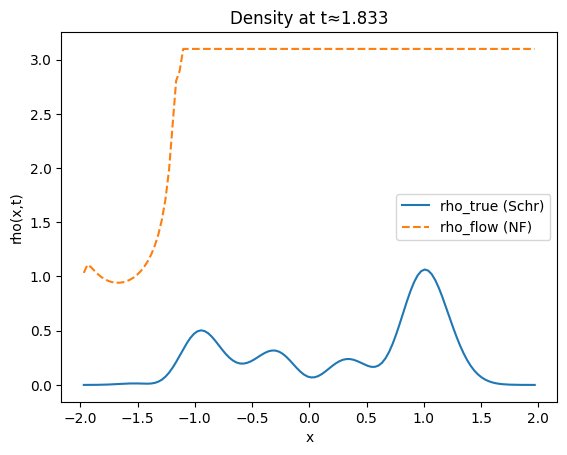

In [3]:
# ============================================================
# Physics-Informed Normalizing Flow to learn rho(x,t) + V(x)
# (FIXED dS/dt pointwise + differentiable flow inverse)
# ============================================================
#
# MENU
# ----
# 1) Synthetic data generator (known V_true, known psi0):
#    - Solve Schrodinger on grid via eigen-decomposition (once).
#    - At many times, sample x ~ rho_true(x,t). These are "measurements".
#
# 2) Model:
#    - Conditional 1D Normalizing Flow rho_phi(x|t) using Rational-Quadratic Spline
#      with analytic inverse (so NLL gradients are correct).
#    - Phase network S_psi(x,t)
#    - Potential network V_theta(x), time-independent
#
# 3) Loss:
#    - NLL from samples:  -E log rho_phi(x|t)
#    - Physics constraints (Madelung):
#        (a) continuity:   d_t rho + d_x(rho * v) = 0, v = (1/m) d_x S
#        (b) HJ:           d_t S + (d_x S)^2/(2m) + V + Q(rho) = 0
#    - V smoothness + gauge fix (remove mean)
#
# IMPORTANT FIX
# -------------
# dS/dt must be pointwise: make t a vector with requires_grad.
# Do NOT do grad(S.sum(), t_scalar) and broadcast (that's wrong).
#
# ============================================================

import math
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -----------------------------
# 0) Repro / device / dtype
# -----------------------------
seed = 0
random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cpu")  # set "cuda" if available
real_dtype = torch.float64
cplx_dtype = torch.complex128

# -----------------------------
# 1) SHORT EXPERIMENT DEFAULTS
# -----------------------------
SHORT = True

if SHORT:
    N_grid   = 128
    N_phys   = 96
    T_times  = 13
    M_per_time = 500
    t_max    = 2.0
    num_steps = 1500
    batch_size = 256
else:
    N_grid   = 256
    N_phys   = 128
    T_times  = 21
    M_per_time = 2000
    t_max    = 3.0
    num_steps = 4000
    batch_size = 1024

# -----------------------------
# 2) Physics settings + domain
# -----------------------------
hbar = 1.0
m = 1.0

xmin, xmax = -2.0, 2.0
dx = (xmax - xmin) / (N_grid + 1)
x_grid = torch.linspace(xmin + dx, xmax - dx, N_grid, device=device, dtype=real_dtype)

def kinetic_energy_matrix_1d(N, dx, hbar=1.0, m=1.0, device=device, dtype=real_dtype):
    main = (-2.0) * torch.ones(N, device=device, dtype=dtype)
    off  = (1.0)  * torch.ones(N - 1, device=device, dtype=dtype)
    D2 = torch.diag(main) + torch.diag(off, diagonal=1) + torch.diag(off, diagonal=-1)
    D2 = D2 / (dx * dx)
    T = -(hbar**2) / (2.0 * m) * D2
    return T

Tmat = kinetic_energy_matrix_1d(N_grid, dx, hbar=hbar, m=m, device=device, dtype=real_dtype)

# ---- Choose a known true potential for data generation ----
def V_true(x):
    # double well
    a = 6.0
    b = 0.7
    return a * (x*x - b*b)**2

Vtrue_vec = V_true(x_grid)
H_true = Tmat + torch.diag(Vtrue_vec)

def propagate_with_eigh(H_real, psi0_cplx, t, hbar=1.0):
    evals, Q = torch.linalg.eigh(H_real)
    phase = torch.exp((-1j) * evals * (t / hbar))
    Qc = Q.to(psi0_cplx.dtype)
    psi_t = Qc @ (phase * (Qc.T @ psi0_cplx))
    return psi_t

# ---- Initial wavefunction (ensure it explores BOTH sides over time) ----
def psi0_packet(x, x0=0.0, sigma=0.35, p0=0.0):
    gaus = torch.exp(-0.5 * ((x - x0) / sigma) ** 2)
    phase = torch.exp(1j * (p0 / hbar) * x.to(cplx_dtype))
    return gaus.to(cplx_dtype) * phase

# Centered packet helps explore symmetrically; you can also try p0 != 0 and larger t_max.
psi0 = psi0_packet(x_grid, x0=0.0, sigma=0.35, p0=2.5)
psi0 = psi0 / torch.sqrt(torch.sum((psi0.conj()*psi0).real) * dx)

# -----------------------------
# 3) Generate synthetic measurement data at many times
# -----------------------------
times = torch.linspace(0.0, t_max, T_times, device=device, dtype=real_dtype)

@torch.no_grad()
def sample_from_density_on_grid(rho, x_grid, M, dx):
    # rho normalized wrt dx
    p = (rho * dx).clamp(min=0.0)
    p = p / p.sum()
    idx = torch.multinomial(p, num_samples=M, replacement=True)
    return x_grid[idx]

rho_true_all = []
x_data_list, t_data_list = [], []

with torch.no_grad():
    for t in times:
        psi_t = propagate_with_eigh(H_true, psi0, t=float(t.item()), hbar=hbar)
        rho = (psi_t.conj()*psi_t).real
        rho = rho / (rho.sum() * dx)
        rho_true_all.append(rho.cpu())

        xs = sample_from_density_on_grid(rho, x_grid, M_per_time, dx=dx)
        x_data_list.append(xs.cpu())
        t_data_list.append(torch.full((M_per_time,), float(t.item()), dtype=real_dtype))

x_data = torch.cat(x_data_list).to(device=device, dtype=real_dtype)
t_data = torch.cat(t_data_list).to(device=device, dtype=real_dtype)

def t_norm(t):
    # map [0,t_max] -> [-1,1]
    return 2.0*(t / t_max) - 1.0

# -----------------------------
# 4) Utility finite differences on uniform grid
# -----------------------------
def fd_first(f, dx):
    out = torch.zeros_like(f)
    out[1:-1] = (f[2:] - f[:-2]) / (2*dx)
    out[0]    = (f[1]  - f[0])   / dx
    out[-1]   = (f[-1] - f[-2])  / dx
    return out

def fd_second(f, dx):
    out = torch.zeros_like(f)
    out[1:-1] = (f[2:] - 2*f[1:-1] + f[:-2]) / (dx*dx)
    out[0]    = out[1]
    out[-1]   = out[-2]
    return out

def quantum_potential_from_logrho(log_rho, dx, hbar=1.0, m=1.0):
    # Q = -(ħ^2/4m) [ d2(log rho) + 0.5 (d(log rho))^2 ]
    dlog_dx  = fd_first(log_rho, dx)
    d2log_dx = fd_second(log_rho, dx)
    Q = -(hbar*hbar)/(4*m) * (d2log_dx + 0.5*(dlog_dx**2))
    return Q

# -----------------------------
# 5) 1D Conditional Rational-Quadratic Spline Flow (analytic inverse)
# -----------------------------
def _normalize_bins(unnorm, min_bin):
    # unnorm: (B,K), return widths that sum to 1 and each >= min_bin
    K = unnorm.shape[1]
    w = F.softmax(unnorm, dim=-1)
    w = min_bin + (1.0 - K*min_bin)*w
    return w

def rational_quadratic_spline(x, widths, heights, derivatives, inverse=False, eps=1e-12):
    """
    x in [0,1], monotone spline mapping [0,1]->[0,1]
    widths: (B,K) sum to 1
    heights:(B,K) sum to 1
    derivatives: (B,K+1) positive
    Returns y and log|dy/dx| (or inverse with log|dx/dy|)
    """
    B, K = widths.shape
    # cumulative knots
    cumwidths  = torch.cumsum(widths, dim=-1)
    cumheights = torch.cumsum(heights, dim=-1)

    cumwidths  = F.pad(cumwidths,  (1,0), value=0.0)  # (B,K+1)
    cumheights = F.pad(cumheights, (1,0), value=0.0)  # (B,K+1)

    # ensure last knot is exactly 1
    cumwidths[:, -1] = 1.0
    cumheights[:, -1] = 1.0

    # find bin indices
    # x shape: (B,) or (B,1)
    x = x.view(B, 1)
    if not inverse:
        bin_idx = torch.sum(x >= cumwidths[:, 1:], dim=-1)  # (B,)
    else:
        bin_idx = torch.sum(x >= cumheights[:, 1:], dim=-1)  # (B,)

    bin_idx = torch.clamp(bin_idx, 0, K-1)

    # gather knot values
    input_cum = cumwidths if not inverse else cumheights
    output_cum = cumheights if not inverse else cumwidths
    bin_widths  = widths
    bin_heights = heights

    x0 = input_cum.gather(1, bin_idx[:,None])
    x1 = input_cum.gather(1, (bin_idx+1)[:,None])
    y0 = output_cum.gather(1, bin_idx[:,None])
    y1 = output_cum.gather(1, (bin_idx+1)[:,None])

    w  = bin_widths.gather(1, bin_idx[:,None])
    h  = bin_heights.gather(1, bin_idx[:,None])

    d0 = derivatives.gather(1, bin_idx[:,None])
    d1 = derivatives.gather(1, (bin_idx+1)[:,None])

    # local coordinate
    if not inverse:
        theta = (x - x0) / (w + eps)
        theta = theta.clamp(0.0, 1.0)
        s = h / (w + eps)

        numerator = h * (s*theta*theta + d0*theta*(1-theta))
        denom = s + (d0 + d1 - 2*s)*theta*(1-theta)
        y = y0 + numerator / (denom + eps)

        # derivative dy/dx
        num_der = s*s*(d1*theta*theta + 2*s*theta*(1-theta) + d0*(1-theta)*(1-theta))
        den_der = (denom + eps)**2
        dy_dx = num_der / den_der
        logabs = torch.log(dy_dx + eps)

        return y[:,0], logabs[:,0]
    else:
        # inverse: given y in [0,1], solve for theta in [0,1]
        y = x  # rename
        s = h / (w + eps)

        # Let u = (y - y0)/h
        u = (y - y0) / (h + eps)
        u = u.clamp(0.0, 1.0)

        # Solve quadratic for theta (see Durkan RQS)
        a = (u*(d0 + d1 - 2*s) + (s - d0))
        b = (u*(2*s - d0 - d1) + d0)
        c = -s*u

        # theta = (2c)/(-b - sqrt(b^2 - 4ac))  (stable root in [0,1])
        disc = b*b - 4*a*c
        disc = torch.clamp(disc, min=0.0)
        sqrt_disc = torch.sqrt(disc + eps)

        theta = (2*c) / (-b - sqrt_disc + eps)
        theta = theta.clamp(0.0, 1.0)

        x_out = x0 + theta * w

        # compute dy/dx at theta, then invert
        denom = s + (d0 + d1 - 2*s)*theta*(1-theta)
        num_der = s*s*(d1*theta*theta + 2*s*theta*(1-theta) + d0*(1-theta)*(1-theta))
        dy_dx = num_der / ((denom + eps)**2)

        dx_dy = 1.0 / (dy_dx + eps)
        logabs = torch.log(dx_dy + eps)

        return x_out[:,0], logabs[:,0]

class CondRQSFlow1D(nn.Module):
    """
    Base z ~ N(0,1)
    u = sigmoid(z) in (0,1)
    y = spline(u; t) in (0,1)
    x = xmin + (xmax-xmin)*y
    """
    def __init__(self, K=16, hidden=(64,64),
                 min_bin_width=1e-3, min_bin_height=1e-3, min_derivative=1e-3):
        super().__init__()
        self.K = K
        self.min_bin_width = min_bin_width
        self.min_bin_height = min_bin_height
        self.min_derivative = min_derivative

        layers = []
        d = 1
        for h in hidden:
            layers += [nn.Linear(d, h), nn.Tanh()]
            d = h
        # outputs: widths(K), heights(K), derivatives(K+1)
        out_dim = K + K + (K+1)
        layers += [nn.Linear(d, out_dim)]
        self.cond = nn.Sequential(*layers)

    def _params(self, t):
        # t: (B,)
        tn = t_norm(t)[:,None]           # (B,1)
        raw = self.cond(tn)              # (B, 2K+K+1)
        K = self.K
        w_raw = raw[:, :K]
        h_raw = raw[:, K:2*K]
        d_raw = raw[:, 2*K:]

        widths  = _normalize_bins(w_raw, self.min_bin_width)
        heights = _normalize_bins(h_raw, self.min_bin_height)
        derivatives = self.min_derivative + F.softplus(d_raw)

        return widths, heights, derivatives

    def forward(self, z, t):
        # z,t: (B,)
        B = z.shape[0]
        widths, heights, derivs = self._params(t)

        u = torch.sigmoid(z)  # (0,1)
        # spline on u
        y, log_dy_du = rational_quadratic_spline(
            u, widths, heights, derivs, inverse=False
        )
        # x scaling
        x = xmin + (xmax - xmin)*y
        # log|dx/dz| = log|dx/dy| + log|dy/du| + log|du/dz|
        # dx/dy = (xmax-xmin)
        log_dx_dy = math.log(xmax - xmin)
        # du/dz = sigmoid(z)*(1-sigmoid(z)) = u(1-u)
        log_du_dz = torch.log(u*(1-u) + 1e-12)

        logabs = log_dx_dy + log_dy_du + log_du_dz
        return x, logabs

    def inverse(self, x, t):
        # x -> y -> u -> z
        B = x.shape[0]
        widths, heights, derivs = self._params(t)

        y = (x - xmin) / (xmax - xmin)
        y = y.clamp(1e-6, 1.0-1e-6)

        u, log_du_dy = rational_quadratic_spline(
            y, widths, heights, derivs, inverse=True
        )
        u = u.clamp(1e-6, 1.0-1e-6)
        z = torch.log(u) - torch.log(1-u)

        # log|dz/dx| = log|dz/du| + log|du/dy| + log|dy/dx|
        # dz/du = 1/(u(1-u))
        log_dz_du = -torch.log(u*(1-u) + 1e-12)
        # dy/dx = 1/(xmax-xmin)
        log_dy_dx = -math.log(xmax - xmin)

        logabs = log_dz_du + log_du_dy + log_dy_dx
        return z, logabs

    def log_prob(self, x, t):
        z, log_dz_dx = self.inverse(x, t)
        log_pz = -0.5*z*z - 0.5*math.log(2*math.pi)
        # log p(x) = log p(z) + log|dz/dx|
        return log_pz + log_dz_dx

    @torch.no_grad()
    def sample(self, n, t_scalar):
        t = torch.full((n,), float(t_scalar), device=device, dtype=real_dtype)
        z = torch.randn(n, device=device, dtype=real_dtype)
        x, _ = self.forward(z, t)
        return x

# -----------------------------
# 6) Phase and Potential networks
# -----------------------------
class PhaseNet(nn.Module):
    def __init__(self, hidden=(64,64)):
        super().__init__()
        layers = []
        d = 2  # x, t
        for h in hidden:
            layers += [nn.Linear(d, h), nn.Tanh()]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        # x,t: (N,)
        inp = torch.stack([x, t_norm(t)], dim=1)
        return self.net(inp)[:,0]

class PotentialNet(nn.Module):
    def __init__(self, hidden=(64,64), Vmax=80.0):
        super().__init__()
        self.Vmax = Vmax
        layers = []
        d = 1
        for h in hidden:
            layers += [nn.Linear(d, h), nn.Tanh()]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        y = self.net(x[:,None])[:,0]
        return self.Vmax * torch.tanh(y)

def gauge_fix(Vx):
    return Vx - Vx.mean()

# -----------------------------
# 7) Build models + training config
# -----------------------------
flow = CondRQSFlow1D(K=16, hidden=(64,64)).to(device=device, dtype=real_dtype)
phase = PhaseNet(hidden=(64,64)).to(device=device, dtype=real_dtype)
Vnet  = PotentialNet(hidden=(64,64), Vmax=90.0).to(device=device, dtype=real_dtype)

opt = torch.optim.Adam(list(flow.parameters()) + list(phase.parameters()) + list(Vnet.parameters()), lr=2e-3)

# weights
lambda_cont = 1.0
lambda_hj   = 1.0
lambda_Vsmooth = 2e-3

# schedule
warmup_steps = 400               # NLL-only first
phys_ramp_steps = 600            # then ramp physics weight
lambda_phys_max = 2.0            # final physics multiplier

# physics evaluation grid
dx_phys = (xmax - xmin) / (N_phys + 1)
x_phys = torch.linspace(xmin + dx_phys, xmax - dx_phys, N_phys, device=device, dtype=real_dtype)

# time FD step for drho/dt
dt_fd = float(times[1].item() - times[0].item()) * 0.5
dt_fd = max(dt_fd, 1e-3)

def phys_weight(step):
    if step < warmup_steps:
        return 0.0
    s = step - warmup_steps
    if s >= phys_ramp_steps:
        return lambda_phys_max
    return lambda_phys_max * (s / phys_ramp_steps)

# -----------------------------
# 8) Training loop
# -----------------------------
loss_hist = []
nll_hist  = []
phys_hist = []
Vsm_hist  = []

for step in range(num_steps):
    opt.zero_grad()

    # --- NLL data loss ---
    idx = torch.randint(0, x_data.shape[0], (batch_size,), device=device)
    xb = x_data[idx]
    tb = t_data[idx]
    logp = flow.log_prob(xb, tb)
    loss_nll = -logp.mean()

    # --- Physics loss at a few random times ---
    B_t = 2 if SHORT else 4
    tidx = torch.randint(0, times.shape[0], (B_t,), device=device)
    t_batch = times[tidx]

    loss_phys = torch.zeros((), device=device, dtype=real_dtype)

    for t0 in t_batch:
        # evaluate log rho on uniform grid
        t0_vec = torch.full_like(x_phys, float(t0.item()), dtype=real_dtype, device=device)
        log_rho0 = flow.log_prob(x_phys, t0_vec)
        # floor to avoid extreme Q blowups in low-density tails
        log_rho0 = torch.clamp(log_rho0, min=-40.0)
        rho0 = torch.exp(log_rho0)

        # drho/dt via time finite difference (still differentiable in params)
        t_plus  = min(float(t0.item()) + dt_fd, t_max)
        t_minus = max(float(t0.item()) - dt_fd, 0.0)
        tp_vec = torch.full_like(x_phys, t_plus, dtype=real_dtype, device=device)
        tm_vec = torch.full_like(x_phys, t_minus, dtype=real_dtype, device=device)

        log_rho_p = flow.log_prob(x_phys, tp_vec)
        log_rho_m = flow.log_prob(x_phys, tm_vec)
        log_rho_p = torch.clamp(log_rho_p, min=-40.0)
        log_rho_m = torch.clamp(log_rho_m, min=-40.0)
        rho_p = torch.exp(log_rho_p)
        rho_m = torch.exp(log_rho_m)
        drho_dt = (rho_p - rho_m) / (t_plus - t_minus + 1e-12)

        # ---- FIXED: pointwise dS/dx and dS/dt ----
        x_req = x_phys.detach().clone().requires_grad_(True)
        t_req = torch.full_like(x_req, float(t0.item()), dtype=real_dtype, device=device).detach().requires_grad_(True)

        S = phase(x_req, t_req)  # (N_phys,)

        dS_dx = torch.autograd.grad(
            S, x_req, grad_outputs=torch.ones_like(S), create_graph=True
        )[0]
        dS_dt = torch.autograd.grad(
            S, t_req, grad_outputs=torch.ones_like(S), create_graph=True
        )[0]

        v = (1.0/m) * dS_dx
        j = rho0 * v
        dj_dx = fd_first(j, dx_phys)

        r_cont = drho_dt + dj_dx

        # HJ residual
        Vx = gauge_fix(Vnet(x_req))
        Qx = quantum_potential_from_logrho(log_rho0, dx_phys, hbar=hbar, m=m)
        r_hj = dS_dt + (dS_dx**2)/(2*m) + Vx + Qx

        loss_phys = loss_phys + (lambda_cont*(r_cont**2).mean() + lambda_hj*(r_hj**2).mean())

    loss_phys = loss_phys / B_t

    # V smoothness regularizer
    Vg = gauge_fix(Vnet(x_phys))
    dVdx = fd_first(Vg, dx_phys)
    loss_Vsmooth = (dVdx**2).mean()

    lam_phys = phys_weight(step)
    loss = loss_nll + lam_phys*loss_phys + lambda_Vsmooth*loss_Vsmooth
    loss.backward()
    opt.step()

    loss_hist.append(float(loss.detach().cpu()))
    nll_hist.append(float(loss_nll.detach().cpu()))
    phys_hist.append(float(loss_phys.detach().cpu()))
    Vsm_hist.append(float(loss_Vsmooth.detach().cpu()))

    if step % 200 == 0:
        print(f"step {step:4d} | loss={loss.item():.4f} | nll={loss_nll.item():.4f} | "
              f"phys={loss_phys.item():.4f} | lam_phys={lam_phys:.3f} | Vsm={loss_Vsmooth.item():.4f}")

# -----------------------------
# 9) Plots: V and rho
# -----------------------------
with torch.no_grad():
    V_learn = gauge_fix(Vnet(x_grid)).cpu()
    V_true_cpu = V_true(x_grid).cpu()

plt.figure()
plt.plot(loss_hist, label="total")
plt.plot(nll_hist, label="nll")
plt.plot([phys_weight(i)*phys_hist[i] for i in range(len(phys_hist))], label="phys*lam")
plt.title("Loss curves")
plt.xlabel("step")
plt.legend()
plt.show()

plt.figure()
plt.plot(x_grid.cpu(), V_true_cpu, label="V_true")
plt.plot(x_grid.cpu(), V_learn, "--", label="V_learned (gauge-fixed)")
plt.title("Potential: true vs learned")
plt.xlabel("x")
plt.ylabel("V(x)")
plt.legend()
plt.show()

# density comparisons at a few times
check_ts = [0.0, 0.5*t_max, 0.9*t_max]
for tt in check_ts:
    j = int(round(tt / t_max * (T_times-1)))
    rho_true_plot = rho_true_all[j]

    with torch.no_grad():
        tvec = torch.full_like(x_grid, float(times[j].item()), dtype=real_dtype, device=device)
        log_rho = flow.log_prob(x_grid, tvec)
        log_rho = torch.clamp(log_rho, min=-40.0)
        rho_flow = torch.exp(log_rho).cpu()

    plt.figure()
    plt.plot(x_grid.cpu(), rho_true_plot, label="rho_true (Schr)")
    plt.plot(x_grid.cpu(), rho_flow, "--", label="rho_flow (NF)")
    plt.title(f"Density at t≈{float(times[j].item()):.3f}")
    plt.xlabel("x")
    plt.ylabel("rho(x,t)")
    plt.legend()
    plt.show()


In [ ]:
§